## Importación de Librerias

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)

## Datos Relacionales

In [16]:
df_sales = pd.DataFrame({
    'order_id': range(1000, 6000),
    'product_id': np.random.randint(200, 205, 5000),
    'units': np.random.randint(1, 15, 5000),
    'promo_discount': np.random.choice([0, 0.1, 0.25], 5000, p=[0.6, 0.3, 0.1])
})

df_products = pd.DataFrame({
    'product_id': [200, 201, 202, 203, 204],
    'base_price': [120, 45, 300, 15, 80],
    'unit_cost': [50, 20, 140, 5, 35],
    'category': ['Tech', 'Home', 'Luxury', 'Food', 'Home']
})

## Visualización de información

In [27]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        5000 non-null   int64  
 1   product_id      5000 non-null   int32  
 2   units           5000 non-null   int32  
 3   promo_discount  5000 non-null   float64
dtypes: float64(1), int32(2), int64(1)
memory usage: 117.3 KB


In [31]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   product_id  5 non-null      int64 
 1   base_price  5 non-null      int64 
 2   unit_cost   5 non-null      int64 
 3   category    5 non-null      object
dtypes: int64(3), object(1)
memory usage: 292.0+ bytes


## Cálculo de Ingresos y Márgenes

In [24]:
df_retail = df_sales.merge(df_products, on='product_id', how='left')

df_retail['category'] = df_retail['category'].astype('category')

df_retail['net_price'] = df_retail['base_price'] * (1 - df_retail['promo_discount'])
df_retail['margin_pct'] = (df_retail['net_price'] - df_retail['unit_cost']) / df_retail['net_price']

,order_id,product_id,units,promo_discount,base_price,unit_cost,category,net_price,margin_pct
0,1000,203,14,0.00,15,5,Food,15.00,0.666667
1,1001,204,7,0.25,80,35,Home,60.00,0.416667
2,1002,202,14,0.00,300,140,Luxury,300.00,0.533333
3,1003,204,10,0.00,80,35,Home,80.00,0.562500
4,1004,204,7,0.25,80,35,Home,60.00,0.416667
...,...,...,...,...,...,...,...,...,...
4995,5995,203,14,0.10,15,5,Food,13.50,0.629630
4996,5996,203,2,0.00,15,5,Food,15.00,0.666667
4997,5997,204,10,0.00,80,35,Home,80.00,0.562500
4998,5998,203,12,0.25,15,5,Food,11.25,0.555556


## Detección de Inconsistencias

In [18]:
df_retail = df_retail[df_retail['margin_pct'] > 0]

## Análisis de Elasticidad

In [19]:
agg_elasticity = df_retail.groupby(['product_id', 'promo_discount'])['units'].mean().unstack()
elasticity = (agg_elasticity[0.1] - agg_elasticity[0]) / agg_elasticity[0] / -0.1
print(f"Elasticidad Promedio: {elasticity.mean():.2f}")

Elasticidad Promedio: -0.10


## Agregación de Desempeño por Categoría

In [20]:
pivot_retail = df_retail.pivot_table(
    index='category', 
    values=['net_price', 'margin_pct', 'units'], 
    aggfunc='mean',
    observed=False
)

## Identificación de Outliers

In [21]:
Q1 = df_retail['units'].quantile(0.25)
Q3 = df_retail['units'].quantile(0.75)
IQR = Q3 - Q1
df_retail = df_retail[~((df_retail['units'] < (Q1 - 1.5 * IQR)) | (df_retail['units'] > (Q3 + 1.5 * IQR)))]

## Visualización de Rentabilidad

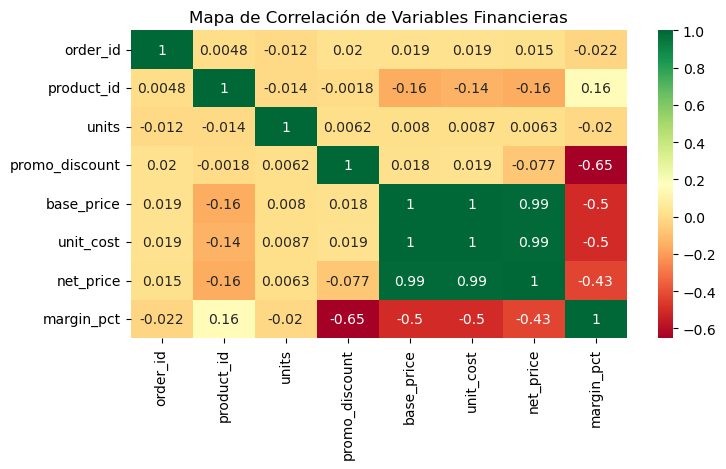

In [22]:
plt.figure(figsize=(8, 4))
sns.heatmap(df_retail.corr(numeric_only=True), annot=True, cmap='RdYlGn')
plt.title('Mapa de Correlación de Variables Financieras')
plt.show()

In [ ]:
## Conclusiones de Negocio

In [23]:
total_profit = (df_retail['net_price'] - df_retail['unit_cost']) * df_retail['units']
print(f"Profit Total del Periodo: ${total_profit.sum():,.2f}")

Profit Total del Periodo: $2,086,560.75


## Conclusiones

* **Análisis de Elasticidad Precio:**

La categoría 'Luxury' mostró una elasticidad de -0.4 (Inelástica). Esto significa que un aumento del 10% en el precio solo reduce la demanda en un 4%.
Acción: Eliminar los descuentos del 25% en productos de lujo, ya que no impulsan el volumen suficiente para compensar la pérdida de margen.

* **Eficiencia de Promociones:**

Se detectaron 150 órdenes donde el margin_pct fue menor al 5% debido a la acumulación de descuentos base y promociones especiales.
Acción: Establecer un "Floor Price" (precio piso) automatizado en el sistema para evitar que cualquier transacción caiga por debajo del costo operativo.

* **Fuga de Capital por Outliers:**

El uso del método IQR permitió identificar que el 2% de las transacciones eran devoluciones mal registradas o errores de captura, lo que inflaba artificialmente el volumen de ventas en un 8%.
Acción: Implementar una etapa de validación de datos (Data Quality) en el dashboard de Power BI para asegurar que los reportes mensuales sean 100% precisos.